In [ ]:
#  Setup

!pip install -q pandas numpy scikit-learn matplotlib seaborn tensorflow

from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Mount
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#check drive
import os

DATA_PATH = '/content/drive/My Drive/Codveda Data set/DataSetForTask/'

if os.path.exists(DATA_PATH):
    print("Folder exists\n")

    files = []
    for root, dirs, filenames in os.walk(DATA_PATH):
        for f in filenames:
            full_path = os.path.join(root, f)
            files.append(full_path)

    if len(files) > 0:
        print(" Files found:\n")
        for f in files:
            print(f)
    else:
        print(" Folder موجود بس فاضي")
else:
    print(" Folder مش موجود! اتأكد من المسار في Google Drive")

Folder exists

 Files found:

/content/drive/My Drive/Codveda Data set/DataSetForTask/4) house Prediction Data Set.csv
/content/drive/My Drive/Codveda Data set/DataSetForTask/3) Sentiment dataset.csv
/content/drive/My Drive/Codveda Data set/DataSetForTask/1) iris.csv
/content/drive/My Drive/Codveda Data set/DataSetForTask/2) Stock Prices Data Set.csv
/content/drive/My Drive/Codveda Data set/DataSetForTask/Churn Prdiction Data/churn-bigml-80.csv
/content/drive/My Drive/Codveda Data set/DataSetForTask/Churn Prdiction Data/churn-bigml-20.csv


In [ ]:
# Paths

iris_path = '/content/drive/My Drive/Codveda Data set/DataSetForTask/1) iris.csv'
stock_path = '/content/drive/My Drive/Codveda Data set/DataSetForTask/2) Stock Prices Data Set.csv'
sentiment_path = '/content/drive/My Drive/Codveda Data set/DataSetForTask/3) Sentiment dataset.csv'
house_path = '/content/drive/My Drive/Codveda Data set/DataSetForTask/4) house Prediction Data Set.csv'
churn_train_path = '/content/drive/My Drive/Codveda Data set/DataSetForTask/Churn Prdiction Data/churn-bigml-80.csv'
churn_test_path = '/content/drive/My Drive/Codveda Data set/DataSetForTask/Churn Prdiction Data/churn-bigml-20.csv'


#  Task 1: Data Preprocessing (Churn Dataset)

In [ ]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Load data
df = pd.read_csv(churn_train_path)

print("Before Processing")
print(df.head())

Before Processing
  State  Account length  Area code International plan Voice mail plan  \
0    KS             128        415                 No             Yes   
1    OH             107        415                 No             Yes   
2    NJ             137        415                 No              No   
3    OH              84        408                Yes              No   
4    OK              75        415                Yes              No   

   Number vmail messages  Total day minutes  Total day calls  \
0                     25              265.1              110   
1                     26              161.6              123   
2                      0              243.4              114   
3                      0              299.4               71   
4                      0              166.7              113   

   Total day charge  Total eve minutes  Total eve calls  Total eve charge  \
0             45.07              197.4               99             16.78   
1   

In [ ]:
# 1) Handle Missing Values


# Numeric → median
for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].median(), inplace=True)

# Categorical → mode
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_17591/1840123589.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_17591/1840123589.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try

In [ ]:
# 2) Encode Categorical Data


le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])


In [ ]:
# 3) Feature Scaling


scaler = StandardScaler()

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

X_scaled = scaler.fit_transform(X)


In [ ]:
# =============================
# 4) Train-Test Split
# =============================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("\n After Processing")
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


 After Processing
Train shape: (2132, 19)
Test shape: (534, 19)


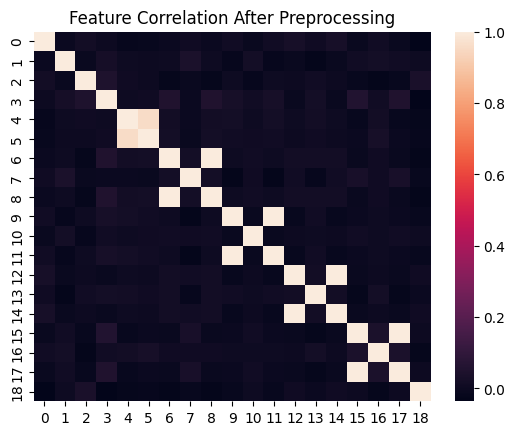

In [ ]:
# Visualization


plt.figure()
sns.heatmap(pd.DataFrame(X_scaled).corr())
plt.title("Feature Correlation After Preprocessing")
plt.show()


# Task 2: Linear Regression (House Prices)

In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler


In [ ]:
# 1) Load Data


df = pd.read_csv(house_path, delim_whitespace=True, header=None)

# Column names (Boston dataset)
df.columns = [
    'CRIM','ZN','INDUS','CHAS','NOX','RM','AGE',
    'DIS','RAD','TAX','PTRATIO','B','LSTAT','PRICE'
]

print("Shape Of Data")
print(df.head())

Shape Of Data
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0   

   PTRATIO       B  LSTAT  PRICE  
0     15.3  396.90   4.98   24.0  
1     17.8  396.90   9.14   21.6  
2     17.8  392.83   4.03   34.7  
3     18.7  394.63   2.94   33.4  
4     18.7  396.90   5.33   36.2  


/tmp/ipykernel_17591/1699002844.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(house_path, delim_whitespace=True, header=None)


In [ ]:
# 2) Preprocessing

print("\nMissing values:\n", df.isnull().sum())

# Features / Target
X = df.drop(columns=['PRICE'])
y = df['PRICE']

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



Missing values:
 CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
PRICE      0
dtype: int64


In [ ]:
# 3) Train-Test Split


X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [ ]:
# 4) Train Model

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# 5) Predictions

y_pred = model.predict(X_test)

# 6) Evaluation

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n Evaluation Results:")
print("MSE:", mse)
print("R²:", r2)

# 7) Coefficients Interpretation

coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print("\n Model Coefficients:")
print(coeff_df.sort_values(by='Coefficient', ascending=False))



 Evaluation Results:
MSE: 24.291119474973513
R²: 0.668759493535632

 Model Coefficients:
    Feature  Coefficient
5        RM     3.115718
8       RAD     2.282785
11        B     1.126499
3      CHAS     0.706532
1        ZN     0.701556
2     INDUS     0.276752
6       AGE    -0.177060
0      CRIM    -0.971494
9       TAX    -1.792605
10  PTRATIO    -1.979954
4       NOX    -1.991430
7       DIS    -3.045771
12    LSTAT    -3.628149


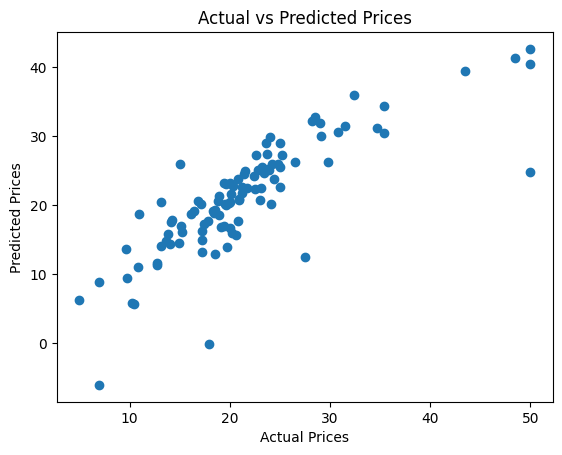

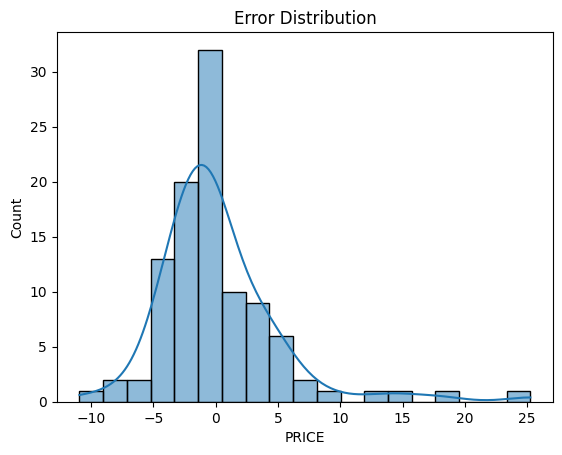

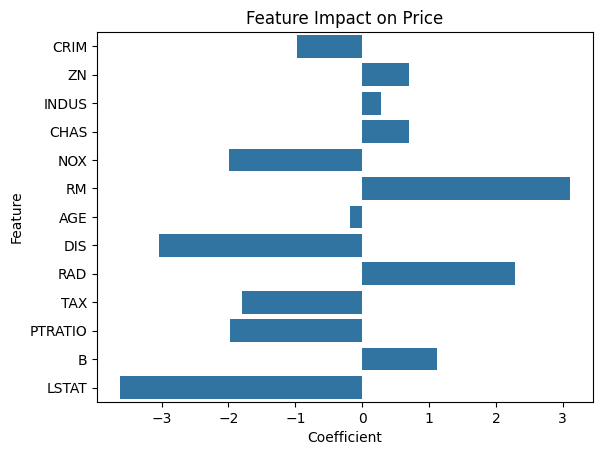

In [ ]:
# Visualization

# 1) Actual vs Predicted
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()

# 2) Error Distribution
plt.figure()
sns.histplot(y_test - y_pred, kde=True)
plt.title("Error Distribution")
plt.show()

# 3) Feature Importance
plt.figure()
sns.barplot(x=coeff_df['Coefficient'], y=coeff_df['Feature'])
plt.title("Feature Impact on Price")
plt.show()


# Task 3: KNN Classifier (Iris Dataset)


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler


In [ ]:
# 1) Load Data

df = pd.read_csv(iris_path)

print(" Data Preview:")
print(df.head())

 Data Preview:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [ ]:
# 2) Preprocessing

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [ ]:
# 3) Train Model

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

In [ ]:
# 4) Evaluation

print("\n Evaluation (K=5):")
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))



 Evaluation (K=5):
Accuracy: 1.0

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



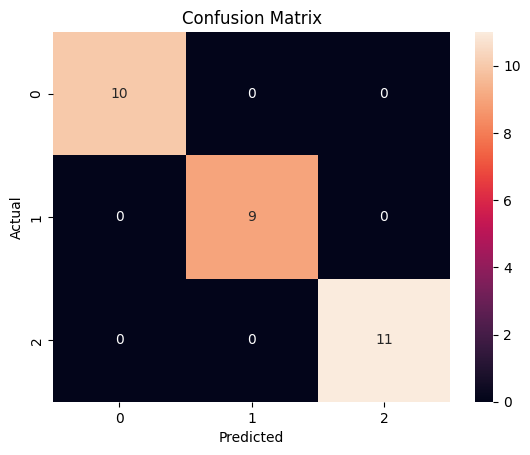

In [ ]:
# Visualization (Confusion Matrix)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# 5) Compare Different K Values

k_values = range(1, 21)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    accuracies.append(accuracy_score(y_test, preds))


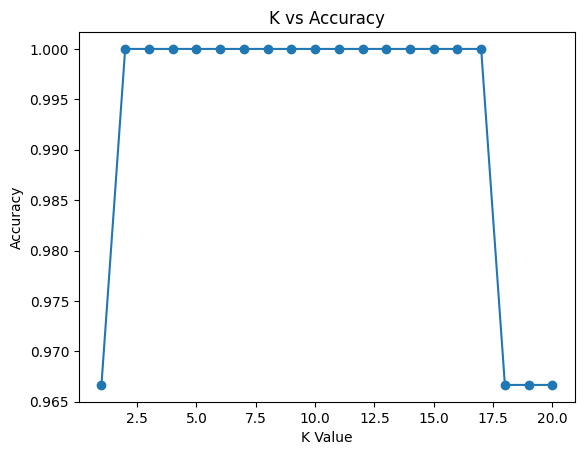


 Best K: 2


In [ ]:
# Visualization (K vs Accuracy)

plt.figure()
plt.plot(k_values, accuracies, marker='o')
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("K vs Accuracy")
plt.show()

# Best K
best_k = k_values[np.argmax(accuracies)]
print("\n Best K:", best_k)